In [2]:
### simple implementation of adaptive sampling

#import modeules

import numpy as np
import matplotlib.pyplot as plt

In [3]:
x = np.linspace(0, 1000, 1000)

y_ = []
for i, j in enumerate(x):
    if j< 180:
        y_.append(np.random.normal(loc = 0.1, scale = 0.1))
    elif j < 800:
        y_.append(np.cos(j/100)*1 + np.random.normal(loc = 0.1 , scale = 0.1))
    else:
        y_.append(np.random.normal(loc = 0.1, scale = 0.10))
y = np.array(y_)

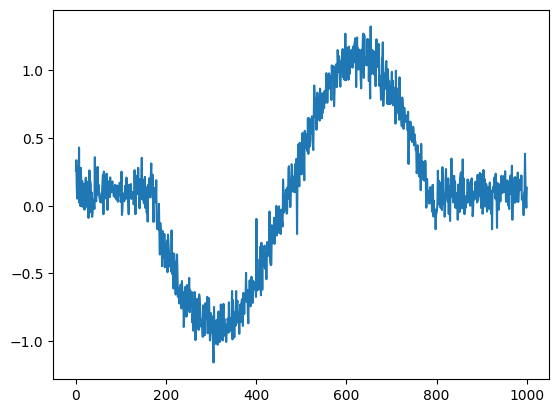

In [4]:
plt.plot(x, y_)

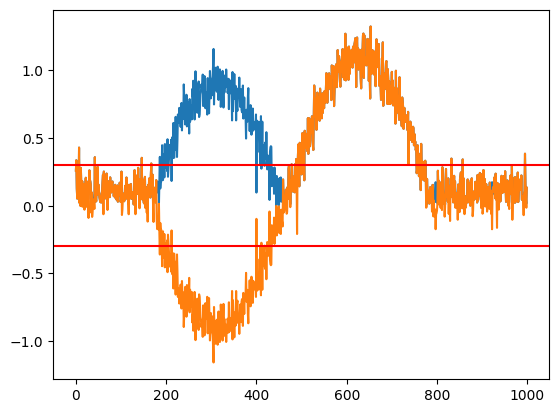

In [5]:
threshold = 0.3
abs_amp = np.abs(y)
high_signal_indices = np.where(abs_amp > threshold)[0]
low_signal_indicies = np.where(abs_amp < threshold)[0]
# visual exmaine the impact of the threshold and which points are selected for over and under sampling
plt.plot(abs_amp)
plt.plot(y)
plt.axhline(y = threshold, color ='r')
plt.axhline(y = -1 * threshold, color ='r')



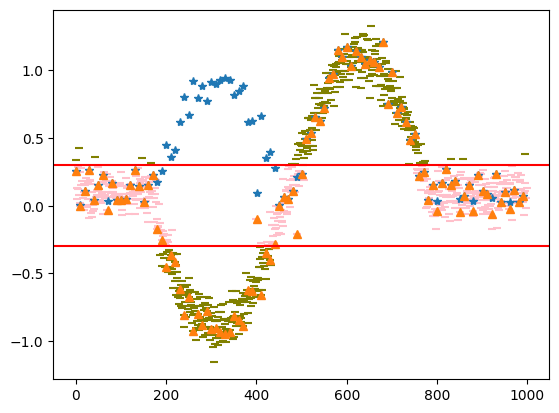

In [6]:
plt.plot(x[::10], abs_amp[::10], '*')
plt.plot(x[::10], y[::10], '^')
plt.scatter(high_signal_indices, y[high_signal_indices], color = 'olive', marker = '_')
plt.scatter(low_signal_indicies, y[low_signal_indicies], color = 'pink', marker = '_')

plt.axhline(y = threshold, color ='r')
plt.axhline(y = -1 * threshold, color ='r')

In [7]:
# set sampling rates

low_signal_samplig_rate = {'conservative_rate' : 0.9,
'moderate_rate' : 0.5,
'agressive_rate' : 0.01
}

sub_sample = int(len(low_signal_indicies) * low_signal_samplig_rate['agressive_rate'])


''' Note -> in high signal area we are going to sample all points'''

subsampled_indicies = np.random.choice(low_signal_indicies, size = sub_sample, replace =  False)


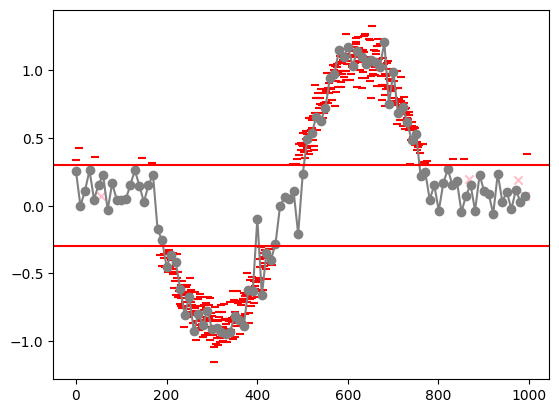

In [8]:
plt.plot(x[::10], y[::10], marker = 'o', color = 'grey')
plt.scatter(high_signal_indices, y[high_signal_indices], color = 'red', marker = '_')
plt.scatter(subsampled_indicies, y[subsampled_indicies], color = 'pink', marker = 'x')

plt.axhline(y = threshold, color ='r')
plt.axhline(y = -1 * threshold, color ='r')

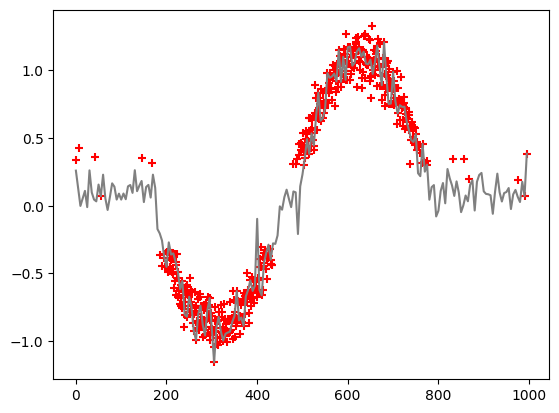

In [19]:
adative_indicies = np.sort(np.concatenate([subsampled_indicies, high_signal_indices]))

plt.scatter(x[adative_indicies], y[adative_indicies], marker = '+', color = 'red')
plt.plot(x[::5], y[::5], color = 'grey')